<a href="https://colab.research.google.com/github/Rudra-iitg/python/blob/main/Titanic_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = sns.load_dataset('titanic')
print(df.shape)
print (df.dtypes)
print(df.isnull().sum())
df.head()

(891, 15)
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


/tmp/ipykernel_4734/4229037743.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['class', 'survived']).size().unstack().plot(kind='bar', ax=axes[2])


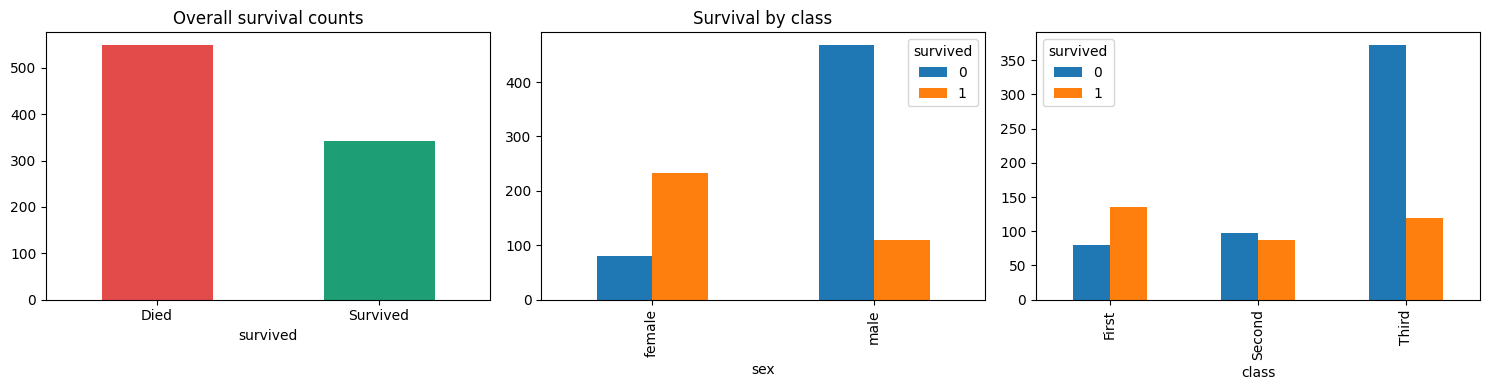

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df.groupby('survived')['survived'].count().plot(kind='bar', ax=axes[0], color=['#E24B4A','#1D9E75'])
axes[0].set_title('Overall survival counts')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)

df.groupby(['sex', 'survived']).size().unstack().plot(kind='bar', ax=axes[1])
axes[1].set_title('Survival by sex')

df.groupby(['class', 'survived']).size().unstack().plot(kind='bar', ax=axes[2])
axes[1].set_title('Survival by class')

plt.tight_layout()
plt.show()

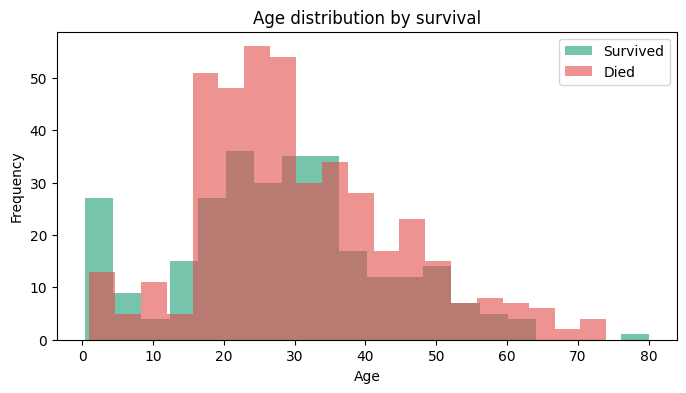

In [ ]:
plt.figure(figsize=(8,4))
df[df.survived==1]['age'].plot(kind='hist', bins=20, alpha=0.6, label='Survived', color='#1D9E75')
df[df.survived==0]['age'].plot(kind='hist', bins=20, alpha=0.6, label='Died', color='#E24B4A')
plt.legend()
plt.title('Age distribution by survival')
plt.xlabel('Age')
plt.show()

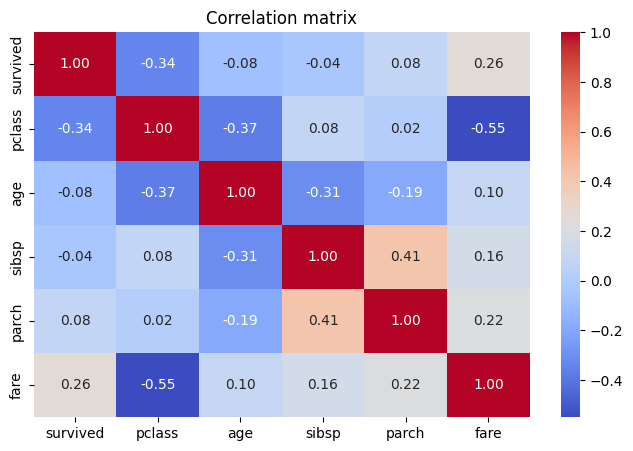

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

In [ ]:
data = df.copy()

In [ ]:
data = df.copy()
data.drop(columns=['deck', 'embark_town', 'alive', 'who', 'adult_male','class', 'alone'], inplace=True, errors='ignore')
data['age'] = data['age'].fillna(data['age'].median())
data['fare'] = data['fare'].fillna(data['fare'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])
data['sex'] = LabelEncoder().fit_transform(data['sex'])
data = pd.get_dummies(data, columns=['embarked'], drop_first=True)
data['family_size'] = data['sibsp'] + data['parch'] + 1
data['is_alone'] = (data['family_size'] == 1).astype(int)
print(data.isnull().sum())
print(data.shape)
data.head()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked_Q     0
embarked_S     0
family_size    0
is_alone       0
dtype: int64
(891, 11)


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,False,True,2,0
1,1,1,0,38.0,1,0,71.2833,False,False,2,0
2,1,3,0,26.0,0,0,7.9250,False,True,1,1
3,1,1,0,35.0,1,0,53.1000,False,True,2,0
4,0,3,1,35.0,0,0,8.0500,False,True,1,1


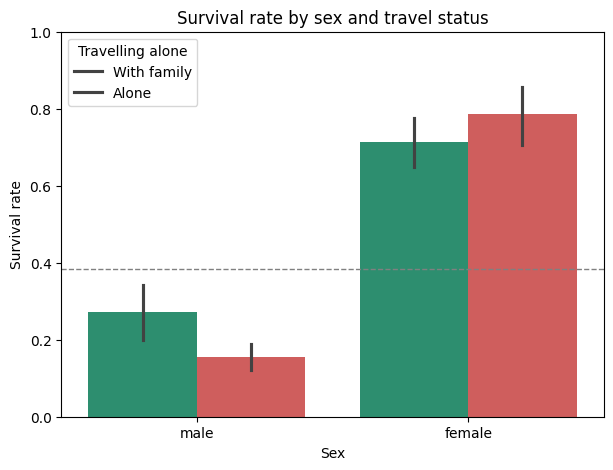

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='sex', y='survived', hue='alone',
            palette={True: '#E24B4A', False: '#1D9E75'})

plt.title('Survival rate by sex and travel status')
plt.ylabel('Survival rate')
plt.xlabel('Sex')
plt.legend(title='Travelling alone', labels=['With family', 'Alone'])
plt.ylim(0, 1)
plt.axhline(0.384, color='gray', linestyle='--', linewidth=1, label='overall average')
plt.show()

In [ ]:
X = data.drop('survived', axis=1)
y = data['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")   # ~712 rows
print(f"Test set:     {X_test.shape}")    # ~179 rows

# Verify stratification worked
print(f"Train survival rate: {y_train.mean():.2%}")
print(f"Test survival rate:  {y_test.mean():.2%}")

Training set: (712, 10)
Test set:     (179, 10)
Train survival rate: 38.34%
Test survival rate:  38.55%


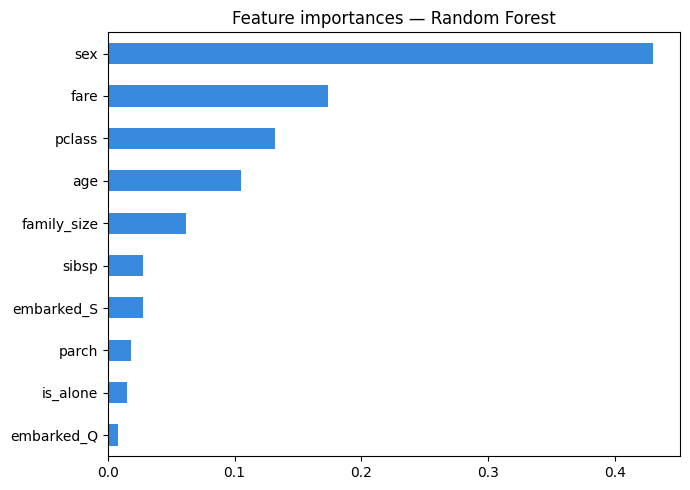

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(7,5), color='#378ADD')
plt.title('Feature importances — Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
def evaluate(name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Died', 'Survived']))


Model: Logistic Regression
Accuracy: 0.8045

Classification Report:
              precision    recall  f1-score   support

        Died       0.82      0.88      0.85       110
    Survived       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



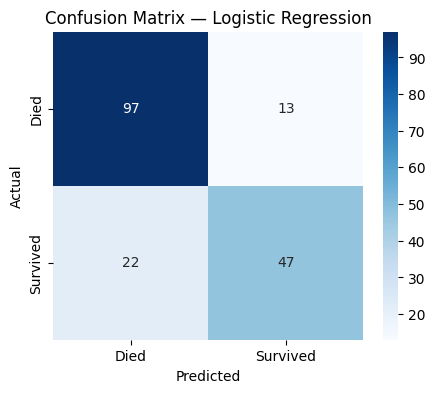


Model: Random Forest
Accuracy: 0.8156

Classification Report:
              precision    recall  f1-score   support

        Died       0.80      0.94      0.86       110
    Survived       0.86      0.62      0.72        69

    accuracy                           0.82       179
   macro avg       0.83      0.78      0.79       179
weighted avg       0.82      0.82      0.81       179



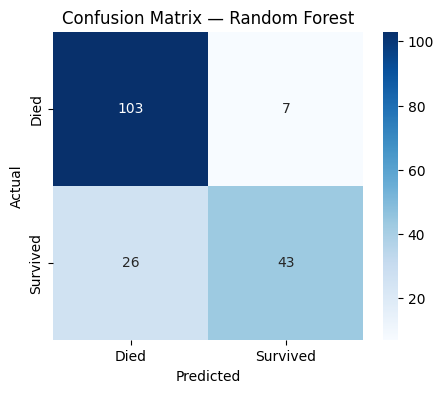


LR  5-fold CV: 0.7935 ± 0.0210
RF  5-fold CV: 0.8193 ± 0.0244


In [ ]:
def evaluate(name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Died', 'Survived']))

    # Confusion Matrix plotting
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Died','Survived'],
                yticklabels=['Died','Survived'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


evaluate("Logistic Regression", y_test, lr_preds)
evaluate("Random Forest",       y_test, rf_preds)

# Cross-validation (more reliable than a single split)
cv_lr = cross_val_score(lr, X, y, cv=5, scoring='accuracy')
cv_rf = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f"\nLR  5-fold CV: {cv_lr.mean():.4f} \u00b1 {cv_lr.std():.4f}")
print(f"RF  5-fold CV: {cv_rf.mean():.4f} \u00b1 {cv_rf.std():.4f}")

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 5, 6],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV score: {grid.best_score_:.4f}")

best_rf = grid.best_estimator_
final_preds = best_rf.predict(X_test)
print(f"Final test accuracy: {accuracy_score(y_test, final_preds):.4f}")

Best params: {'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.8245
Final test accuracy: 0.7933
